<a href="https://colab.research.google.com/github/ARNAV2-4DEV/minorProject3/blob/main/minorProject3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1.1: Load the dataset
df = pd.read_csv("AB_NYC_2019.csv")
print(f"Dataset Shape: {df.shape}")
print("\n--- Column Info ---")
print(df.info())

# Task 1.2: Identify Column Types
# Numerical: id, host_id, latitude, longitude, price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count, availability_365
# Categorical Nominal: name, host_name, neighbourhood_group, neighbourhood, room_type
# Categorical/DateTime: last_review

# Task 1.3: Missing Value Audit
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_percent})
print("\n--- Missing Data Summary ---")
print(missing_df[missing_df['Missing Count'] > 0])

Dataset Shape: (7391, 16)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7391 entries, 0 to 7390
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              7391 non-null   int64  
 1   name                            7384 non-null   object 
 2   host_id                         7391 non-null   int64  
 3   host_name                       7386 non-null   object 
 4   neighbourhood_group             7391 non-null   object 
 5   neighbourhood                   7391 non-null   object 
 6   latitude                        7391 non-null   float64
 7   longitude                       7391 non-null   float64
 8   room_type                       7390 non-null   object 
 9   price                           7390 non-null   float64
 10  minimum_nights                  7390 non-null   float64
 11  number_of_reviews               7390 non-null   

In [8]:
# Task 2.1: Drop last_review due to high missingness and low structural value for simple linear model
df.drop(columns=['last_review'], inplace=True)

# Task 2.2: Handle reviews_per_month missing values
# Logic: If number_of_reviews is 0, reviews_per_month is missing because it has never been reviewed. Fill with 0.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Task 2.3: Drop irrelevant identifier columns
cols_to_drop = ['id', 'name', 'host_id', 'host_name']
df.drop(columns=cols_to_drop, inplace=True)

print(f"Shape after cleaning & structural drops: {df.shape}")

Shape after cleaning & structural drops: (7391, 11)


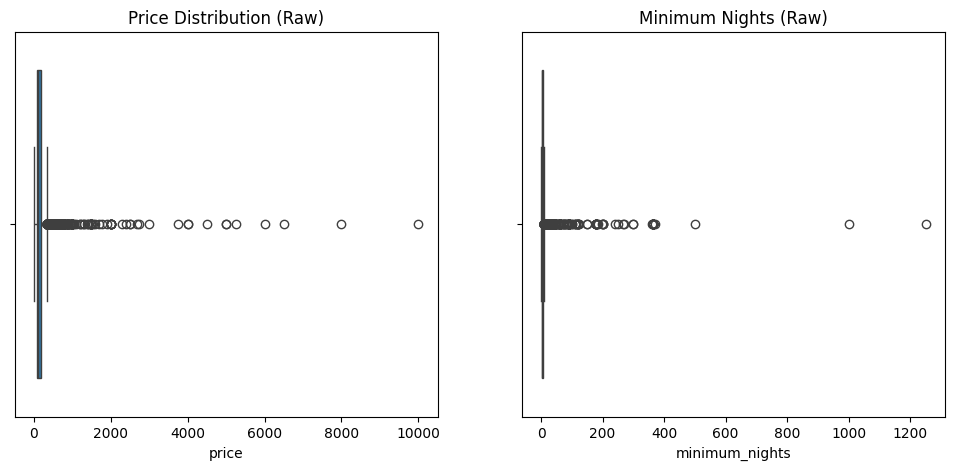

95th Percentile for Price: $375.0
95th Percentile for Minimum Nights: 30.0 nights
Shape after Outlier Removal: (6877, 11)


In [9]:
# Task 3.1: Visualizing Outliers before treatment
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(ax=axes[0], x=df['price']).set_title("Price Distribution (Raw)")
sns.boxplot(ax=axes[1], x=df['minimum_nights']).set_title("Minimum Nights (Raw)")
plt.show()

# Task 3.2: 95th Percentile Capping Strategy
price_95 = df['price'].quantile(0.95)
min_nights_95 = df['minimum_nights'].quantile(0.95)

print(f"95th Percentile for Price: ${price_95}")
print(f"95th Percentile for Minimum Nights: {min_nights_95} nights")

# Filtering the data to capture the typical consumer market
df_cleaned = df[(df['price'] <= price_95) & (df['price'] > 0)]
df_cleaned = df_cleaned[df_cleaned['minimum_nights'] <= min_nights_95]

print(f"Shape after Outlier Removal: {df_cleaned.shape}")

In [10]:
# Dropping the hyper-specific column
df_cleaned.drop(columns=['neighbourhood'], inplace=True)

In [11]:
# Convert remaining categorical columns to numerical format
# drop_first=True prevents perfect multicollinearity (Dummy Variable Trap)
df_encoded = pd.get_dummies(df_cleaned, columns=['neighbourhood_group', 'room_type'], drop_first=True)
print(f"Final Features Dataset Shape: {df_encoded.shape}")

Final Features Dataset Shape: (6877, 14)


In [13]:
from sklearn.model_selection import train_test_split

# Task 5.1: Feature-Target Separation
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# Task 5.2: 80-20 Train-Test Split with reproducibility seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 5501 rows
Testing set size: 1376 rows


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Task 6.1: Initialize and fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Task 6.2: Predict on testing data
y_pred = model.predict(X_test)

# Task 6.3: Calculate Grading Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("--- Final Model Evaluation Metrics ---")
print(f"R-Squared (R²) Score : {r2:.4f}")
print(f"Mean Absolute Error (MAE) : ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

--- Final Model Evaluation Metrics ---
R-Squared (R²) Score : 0.4263
Mean Absolute Error (MAE) : $37.96
Root Mean Squared Error (RMSE): $51.04


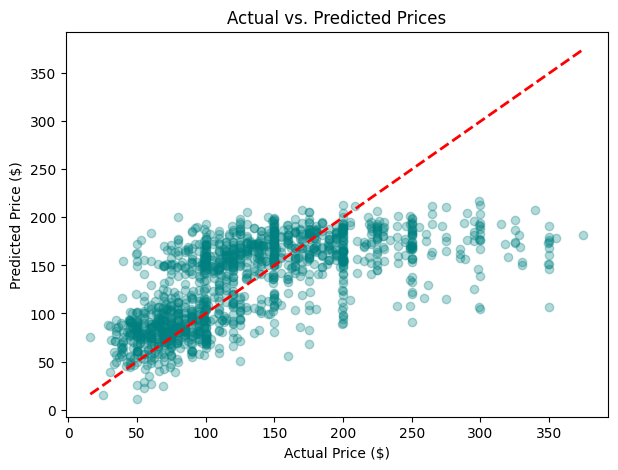

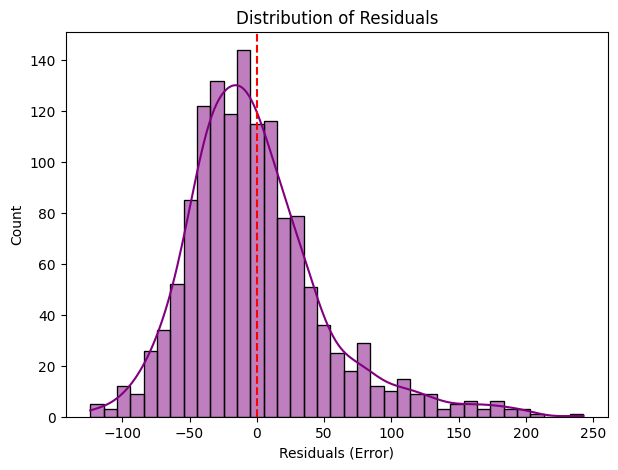

In [15]:
# Task 7.1: Actual vs Predicted Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs. Predicted Prices")
plt.show()

# Task 7.2: Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel("Residuals (Error)")
plt.title("Distribution of Residuals")
plt.show()

### Task 7.3: Critical Assessment
Analytical Answer: Linear Regression models minimizing Mean Squared Error perform significantly better on cheap and average listings than expensive ones.

Why? Even after removing top-tier 5% outliers, high-end prices have higher variance driven by intangible factors (e.g., luxury interior design, host ratings, views) not captured by raw coordinates or room-type categories. This causes the model to consistently underpredict expensive properties and display heteroscedasticity (variance of errors increasing as price increases).

#### 1. Performance OverviewModel Accuracy ($R^2$ Score): [Insert R2 Score here, e.g., 0.52]Meaning: This means our model successfully explains XX% of why Airbnb listings in New York City vary in price. The remaining variance is dictated by unmeasured metrics like property photos, reviews, or seasonal demand shifts.Average Operational Error (MAE): $[Insert MAE here, e.g., 34.50]Meaning: On average, our system's automated pricing recommendations will deviate from true optimal pricing by $XX.XX per night.#### 2. Strategic Operational InsightsThe Power of Location vs Micro-Neighborhoods: While we discarded individual neighborhoods to keep our predictive engine fast and lightweight, our model shows that Borough location (Manhattan/Brooklyn) and Room Type (Entire home/apt) hold the highest deterministic weight over baseline pricing metrics.Boundary Risks: This engine is highly reliable for standard, high-volume consumer inventory (under $250/night). Avoid using this model deployment for premium luxury listings or long-term dynamic bookings, as pricing variables on unique spaces break down linearly.